# Clasificación de artículos mediante árboles de decisión (CART)

## Objetivo

En este notebook se construirá un modelo de clasificación basado en árboles de decisión CART (Classification and Regression Trees) utilizando las métricas relacionales obtenidas a partir del grafo de citaciones del conjunto de datos Cora.

El objetivo es predecir la categoría temática de cada artículo científico a partir de características derivadas de la estructura de la red, como el grado, la centralidad, el coeficiente de agrupamiento, PageRank y la pertenencia a comunidades.

Para ello se seguirá el flujo habitual de un problema de aprendizaje supervisado:

1. Carga de datos.
2. Preparación de atributos y variable objetivo.
3. División en conjuntos de entrenamiento y prueba.
4. Entrenamiento de un árbol CART inicial.
5. Validación cruzada.
6. Optimización de hiperparámetros mediante GridSearchCV.
7. Evaluación del modelo final.
8. Análisis de la importancia de las variables.


## Importación de librerías

Se importan las bibliotecas necesarias para la manipulación de datos, construcción del modelo CART, validación y evaluación de resultados.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Carga del conjunto de datos

Se carga el conjunto de datos generado en el notebook de métricas relacionales. Cada fila representa un artículo científico y cada columna contiene una característica derivada del análisis de la red de citaciones.

La variable objetivo es la clase temática del artículo.


In [3]:
datos_modelo = pd.read_csv(
    "../data/processed/cora_metricas_relacionales.csv"
)

datos_modelo.head()

,articulo_id,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,louvain_community,clase
0,1033,5,0.001847,0.002430,0.181710,0.100000,0.000212,21,Genetic_Algorithms
1,35,168,0.062061,0.232488,0.222769,0.011406,0.025159,21,Genetic_Algorithms
2,103482,6,0.002216,0.004510,0.186238,0.133333,0.000497,3,Neural_Networks
3,103515,11,0.004064,0.001681,0.180501,0.163636,0.000589,21,Genetic_Algorithms
4,1050679,4,0.001478,0.024078,0.207347,0.166667,0.000126,21,Genetic_Algorithms


## Inspección inicial de los datos

Se verifica la estructura del conjunto de datos que será utilizado para entrenar el modelo.


In [4]:
print("Número de instancias:", datos_modelo.shape[0])
print("Número de variables:", datos_modelo.shape[1])

datos_modelo.info()

Número de instancias: 2708
Número de variables: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2708 entries, 0 to 2707
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   articulo_id             2708 non-null   int64  
 1   degree                  2708 non-null   int64  
 2   degree_centrality       2708 non-null   float64
 3   betweenness_centrality  2708 non-null   float64
 4   closeness_centrality    2708 non-null   float64
 5   clustering_coefficient  2708 non-null   float64
 6   pagerank                2708 non-null   float64
 7   louvain_community       2708 non-null   int64  
 8   clase                   2708 non-null   object 
dtypes: float64(5), int64(3), object(1)
memory usage: 190.5+ KB


## Definición de atributos y variable objetivo

En aprendizaje supervisado se distinguen dos componentes:

* Los atributos o variables predictoras (X), que contienen la información utilizada para realizar la predicción.
* La variable objetivo (y), que representa la categoría que se desea predecir.

En este proyecto se utilizarán exclusivamente métricas relacionales obtenidas a partir del grafo de citaciones.


In [7]:
X = datos_modelo.drop(
    columns=["articulo_id", "clase"]
)

y = datos_modelo["clase"]
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (2708, 7)
Dimensiones de y: (2708,)


Es decir, cada artículo tiene asociada una clase temática.

In [8]:
X.columns

Index(['degree', 'degree_centrality', 'betweenness_centrality',
       'closeness_centrality', 'clustering_coefficient', 'pagerank',
       'louvain_community'],
      dtype='object')

## División en conjuntos de entrenamiento y prueba

Para evaluar correctamente el rendimiento del modelo es necesario separar los datos en dos subconjuntos:

* Conjunto de entrenamiento: utilizado para aprender el modelo.
* Conjunto de prueba: utilizado únicamente para evaluar su capacidad de generalización sobre datos no vistos durante el entrenamiento.

Se utilizará una división del 80% para entrenamiento y del 20% para prueba.

Además, se empleará una partición estratificada (`stratify=y`) para mantener aproximadamente la misma proporción de clases en ambos subconjuntos.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=357823,
    stratify=y #Con stratify mantenemos proporciones similares en ambos conjuntos y la evaluación es más fiable.
)

In [11]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2166, 7)
X_test: (542, 7)
y_train: (2166,)
y_test: (542,)


## Entrenamiento de un árbol CART inicial

Como primera aproximación se construirá un árbol de decisión con una profundidad limitada. Este modelo servirá como referencia inicial antes de realizar la optimización de hiperparámetros.

Los árboles de decisión generan reglas de clasificación a partir de divisiones sucesivas de los datos. Cada nodo interno representa una condición sobre una variable, mientras que las hojas representan las clases predichas.

En esta primera versión se utilizará una profundidad máxima de 4 niveles para evitar árboles excesivamente complejos.


In [13]:
cart = DecisionTreeClassifier(
    max_depth=4,
    random_state=357823
)

In [16]:
#Entrenamiento
cart.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,357823
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
#El árbol intentará clasificar artículos que nunca ha visto
y_pred = cart.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5940959409594095


In [21]:
print("Clases predichas:")

print(set(y_pred))

Clases predichas:
{'Theory', 'Genetic_Algorithms', 'Neural_Networks', 'Case_Based', 'Reinforcement_Learning', 'Probabilistic_Methods'}


### Interpretación inicial

El árbol de decisión CART básico obtiene una precisión del 59.4% sobre el conjunto de prueba.

Teniendo en cuenta que el problema consta de siete categorías diferentes y que únicamente se utilizan métricas relacionales derivadas de la estructura del grafo, este resultado puede considerarse una primera aproximación razonable.

Además, el modelo es capaz de predecir correctamente seis de las siete clases presentes en el conjunto de datos. La única categoría que no aparece entre las predicciones es *Rule_Learning*, que corresponde a una de las clases menos representadas del dataset.


## Validación cruzada

La validación cruzada permite obtener una estimación más robusta del rendimiento del modelo.

En lugar de utilizar una única partición de entrenamiento y prueba, los datos se dividen en varios subconjuntos o *folds*. El modelo se entrena y evalúa varias veces utilizando diferentes particiones, obteniéndose finalmente una medida promedio de rendimiento.

De este modo se reduce la dependencia respecto a una única división de los datos y se obtiene una estimación más fiable de la capacidad de generalización del modelo.
    

In [22]:
resultados_cv = cross_validate(
    cart,
    X_train,
    y_train,
    scoring="accuracy",
    cv=10
)

In [25]:
print("Accuracy por fold:")
print(resultados_cv["test_score"])

Accuracy por fold:
[0.61290323 0.64516129 0.62211982 0.59907834 0.62672811 0.55299539
 0.58796296 0.51851852 0.5787037  0.58796296]


In [26]:
print(
    "Accuracy medio:",
    resultados_cv["test_score"].mean()
)

Accuracy medio: 0.5932134323263354


In [27]:
print(
    "Desviación estándar:",
    resultados_cv["test_score"].std()
)

Desviación estándar: 0.03541463786512236


### Interpretación de la validación cruzada

La validación cruzada de 10 particiones produce una precisión media del 59.3%, muy similar a la obtenida previamente sobre el conjunto de prueba (59.4%). Esta similitud sugiere que el modelo presenta un comportamiento estable y que el resultado no depende significativamente de una partición concreta de los datos.

La desviación estándar obtenida es de aproximadamente 0.035, lo que indica una variabilidad moderada entre los distintos folds. En conjunto, estos resultados muestran que el árbol CART básico posee una capacidad de generalización razonable sobre el conjunto de datos Cora.


## Optimización de hiperparámetros mediante GridSearchCV

Los árboles de decisión disponen de diversos hiperparámetros que influyen directamente en su comportamiento y rendimiento. Entre ellos destacan la profundidad máxima del árbol y el número mínimo de muestras necesarias para realizar una división.

Con el objetivo de encontrar la configuración más adecuada para el conjunto de datos Cora, se utilizará GridSearchCV. Este procedimiento evalúa sistemáticamente múltiples combinaciones de hiperparámetros mediante validación cruzada y selecciona aquella que obtiene el mejor rendimiento medio.


In [31]:
cart_grid = DecisionTreeClassifier(
    random_state=357823
)
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, 12, 15],
    "min_samples_split": [2, 5, 10, 20]
}

In [32]:
grid = GridSearchCV(
    estimator=cart_grid,
    param_grid=param_grid,
    scoring="accuracy",
    cv=10,
    n_jobs=-1
)

In [33]:
#Entrenamiento
grid.fit(X_train, y_train)

,estimator,DecisionTreeC..._state=357823)
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [34]:
print("Mejores parámetros:")
print(grid.best_params_)

Mejores parámetros:
{'max_depth': 10, 'min_samples_split': 20}


In [35]:
print("Mejor accuracy medio:")
print(grid.best_score_)

Mejor accuracy medio:
0.7294269499914662


### Resultados de la optimización

El proceso de búsqueda de hiperparámetros mediante GridSearchCV seleccionó como mejor configuración un árbol con profundidad máxima igual a 10 y un mínimo de 20 muestras para realizar una división.

La precisión media obtenida mediante validación cruzada fue del 72.9%, lo que supone una mejora significativa respecto al árbol inicial, cuya precisión era cercana al 59%.

Estos resultados indican que una mayor profundidad permite capturar patrones más complejos presentes en las métricas relacionales, mientras que la restricción sobre el número mínimo de muestras ayuda a controlar el sobreajuste.


In [36]:
mejor_cart = grid.best_estimator_

In [37]:
#Predicciones
y_pred = mejor_cart.predict(X_test)

In [38]:
accuracy_final = accuracy_score(y_test, y_pred)

print("Accuracy final:", accuracy_final)

Accuracy final: 0.7306273062730627


In [39]:
#Informe de clasificación
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

            Case_Based       0.80      0.53      0.64        60
    Genetic_Algorithms       0.91      0.92      0.91        84
       Neural_Networks       0.78      0.76      0.77       164
 Probabilistic_Methods       0.73      0.71      0.72        85
Reinforcement_Learning       0.75      0.88      0.81        43
         Rule_Learning       0.45      0.58      0.51        36
                Theory       0.57      0.61      0.59        70

              accuracy                           0.73       542
             macro avg       0.71      0.71      0.71       542
          weighted avg       0.74      0.73      0.73       542



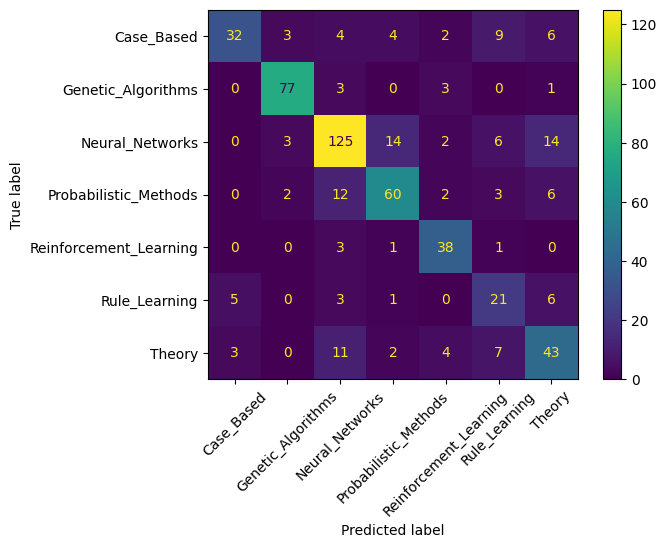

In [42]:
#matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=mejor_cart.classes_
)

disp.plot(
    xticks_rotation=45
)
plt.savefig("../reports/matriz_confusion_cart.png")
plt.show()

### Evaluación del modelo CART optimizado

El árbol de decisión optimizado alcanza una precisión global del 73.1% sobre el conjunto de prueba, mejorando significativamente los resultados obtenidos por el modelo inicial.

Las categorías Genetic_Algorithms y Reinforcement_Learning presentan los mejores resultados, con valores F1 superiores a 0.8. Por el contrario, Rule_Learning constituye la clase más difícil de identificar, probablemente debido a su menor representación dentro del conjunto de datos.

La matriz de confusión muestra que la mayoría de las predicciones correctas se concentran en la diagonal principal, lo que indica un comportamiento adecuado del clasificador. Las principales confusiones aparecen entre las categorías Neural_Networks, Theory y Probabilistic_Methods, sugiriendo que comparten características relacionales similares dentro de la red de citaciones.

En conjunto, los resultados obtenidos demuestran que las métricas relacionales extraídas del grafo contienen información suficiente para realizar una clasificación temática razonablemente precisa de los artículos científicos.


In [47]:
#Importancia de las variables
importancias = pd.DataFrame({
    'feature': X.columns,
    'importance': mejor_cart.feature_importances_
}).sort_values(by='importance', ascending=False)

importancias

,feature,importance
6,louvain_community,0.851317
3,closeness_centrality,0.094796
5,pagerank,0.016683
4,clustering_coefficient,0.015332
2,betweenness_centrality,0.013650
0,degree,0.004863
1,degree_centrality,0.003359


# Importancia de variables en el modelo CART

El modelo CART entrenado permite analizar qué métricas del grafo son más relevantes para la clasificación de artículos en el dataset Cora.

Los resultados obtenidos muestran la siguiente distribución de importancias:

- **louvain_community → 0.8513**
- closeness_centrality → 0.0948  
- pagerank → 0.0167  
- clustering_coefficient → 0.0153  
- betweenness_centrality → 0.0137  
- degree → 0.0049  
- degree_centrality → 0.0034  

---

## Interpretación de resultados

### Variable dominante

La variable más importante con diferencia es **louvain_community**, con más del 85% de la importancia total.

Esto indica que la estructura comunitaria del grafo es el principal factor utilizado por el modelo para realizar la clasificación.

---

### Variables de relevancia secundaria

La variable **closeness_centrality** presenta una importancia moderada (~9.5%), lo que sugiere que la posición global del nodo dentro del grafo aporta cierta información adicional al modelo, aunque muy inferior a la influencia de las comunidades.

---

### Variables con impacto marginal

El resto de métricas (PageRank, clustering coefficient, betweenness centrality, degree y degree centrality) tienen una importancia muy reducida.

Esto indica que las propiedades locales o de centralidad individual no son suficientes por sí solas para explicar la clasificación de los nodos.

---

## Conclusión científica

El análisis del modelo permite extraer la siguiente conclusión:

> La pertenencia a comunidades dentro del grafo (estructura global) es mucho más informativa que las métricas de centralidad local para la clasificación de artículos en el dataset Cora.

Esto implica que:

- La estructura modular del grafo es el principal factor predictivo
- Las comunidades detectadas capturan la mayor parte de la señal relevante
- Las métricas de centralidad actúan únicamente como información complementaria

---


In [49]:
from sklearn.tree import plot_tree

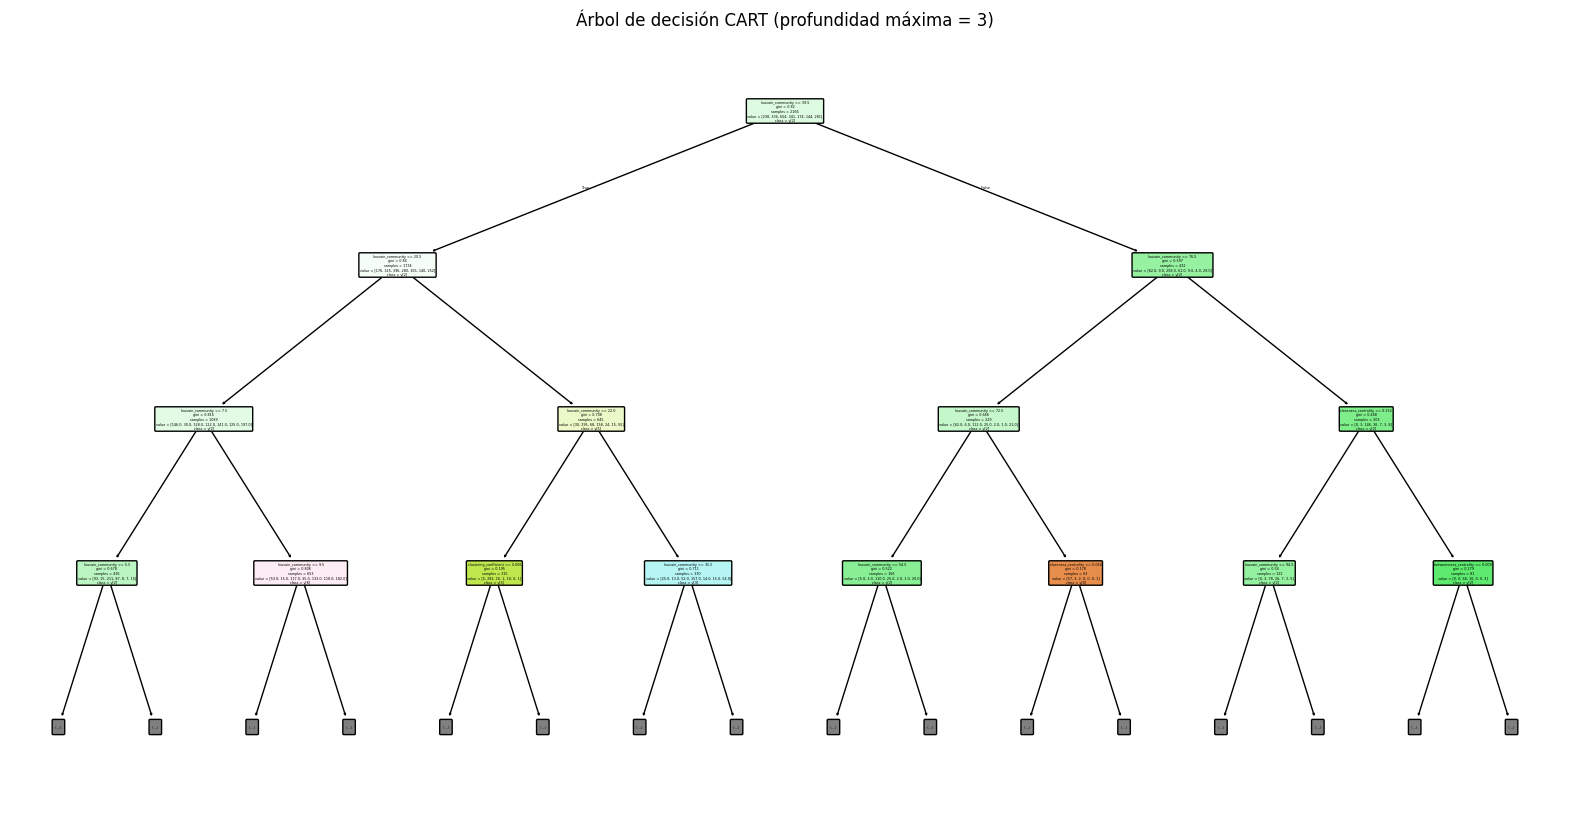

In [50]:
#Visualización del árbol
plt.figure(figsize=(20, 10))

plot_tree(
    mejor_cart,
    feature_names=[
        'degree',
        'degree_centrality',
        'betweenness_centrality',
        'closeness_centrality',
        'clustering_coefficient',
        'pagerank',
        'louvain_community'
    ],
    class_names=True,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Árbol de decisión CART (profundidad máxima = 3)")

plt.savefig("../reports/cart_tree.png")
plt.show()


# Visualización del árbol de decisión CART

Para interpretar el comportamiento del modelo, se muestra el árbol de decisión con una profundidad máxima de 3 niveles, con el objetivo de mantener la interpretabilidad.

- El árbol de decisión confirma los resultados obtenidos en el análisis de importancias:
- Las primeras divisiones del modelo se realizan principalmente sobre la variable louvain_community.
- Esto indica que la separación inicial de los datos depende de la estructura comunitaria del grafo.
- A medida que aumenta la profundidad, aparecen variables como closeness_centrality, aunque con menor relevancia.
- El resto de métricas tiene un papel prácticamente residual.